<div style="background:linear-gradient(90deg,#1A2E4A 0%,#2E5E9B 100%);color:white;padding:20px 26px;border-radius:12px;">
<span style="font-size:12px;letter-spacing:3px;color:#D6E8F7;">CURSO IA APLICADA A CIENCIA DE MATERIALES &nbsp;·&nbsp; DÍA 5 · SOLUCIÓN DEL INSTRUCTOR</span><br>
<span style="font-size:26px;font-weight:700;">🔥 Brief A: Termoeléctricos · solución completa</span><br>
<span style="font-size:14px;color:#D6E8F7;">Lista corta de 10 candidatos para recuperar calor del escape (400 a 700 °C)</span>
</div>

**Para el instructor.** Es una de muchas soluciones válidas. Sirve como vara de comparación
durante el checkpoint y las presentaciones, no como respuesta única.

**Idea central de esta solución:** antes de modelar, mirar bien los datos. El catálogo trae
800 filas, pero solo **49 materiales distintos** medidos varias veces, con mucha dispersión.
Eso cambia todo: cómo se valida un modelo, qué significa "confianza" y cómo se arma la lista.

| Criterio de la rúbrica | Dónde se responde |
|---|---|
| Razonamiento del pipeline (40 %) | Secciones 1 y 2: hallazgos del EDA, validación agrupada por fórmula, por qué no hace falta un modelo para ordenar |
| Calidad del resultado (25 %) | Sección 3: línea base, dispersión, análisis de sensibilidad de la lista |
| Comunicación al cliente (25 %) | Sección 4: dos figuras y un párrafo sin jerga |
| Limitaciones (10 %) | Sección 5 |

In [1]:
import matplotlib.pyplot as plt
from cycler import cycler
AZUL, NARANJA, PURPURA, VERDE = "#2E5E9B", "#D96F0F", "#B0509E", "#2F9E44"
TINTA, GRIS = "#1A2E4A", "#8A94A3"
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=[AZUL, NARANJA, PURPURA, VERDE]),
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TINTA, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "lines.linewidth": 2.0, "figure.dpi": 105, "legend.frameon": False,
})

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score
from pathlib import Path
def encontrar_datos() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents[:3]]:
        if (base / "datos").is_dir():
            return base / "datos"
    raise FileNotFoundError("No encuentro la carpeta datos/")
DATOS = encontrar_datos()
df = pd.read_csv(DATOS / "brief_A_termoelectricos.csv")
MAGPIE = [c for c in df.columns if c.startswith("MagpieData")]
print(f"Catálogo: {df.shape[0]} filas × {df.shape[1]} columnas")

Catálogo: 800 filas × 14 columnas


<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 1. EDA: cuatro hallazgos antes de modelar</b></div>

### Hallazgo 1: 800 filas, pero solo 49 materiales

In [3]:
por_formula = df.groupby("formula").size()
print(f"Fórmulas distintas: {df.formula.nunique()}  (cada una aparece entre {por_formula.min()} y {por_formula.max()} veces)")
print(f"Familias: {df.grupo.nunique()}")
df.groupby("grupo").agg(filas=("formula", "size"), materiales=("formula", "nunique"),
                        ZT_mediana=("ZT_estimated", "median"), costo_mediana=("costo_relativo", "median")
                        ).sort_values("ZT_mediana", ascending=False).round(2)

Fórmulas distintas: 49  (cada una aparece entre 6 y 39 veces)
Familias: 10


,filas,materiales,ZT_mediana,costo_mediana
grupo,,,,
Bi-chalcogenide,76,5,2.02,2.64
Half-Heusler,94,5,1.46,1.23
Telluride-other,83,5,0.79,2.30
Pb-chalcogenide,81,5,0.76,1.78
Clathrate,60,4,0.72,2.06
Skutterudite,74,5,0.38,3.72
Silicide,73,5,0.17,0.81
Antimonide,65,5,0.12,1.57
Other,54,5,0.03,1.00


Cada fórmula es un **material medido o estimado varias veces** (distintas fuentes, muestras o
condiciones). Consecuencias:

- La lista corta debe tener **10 fórmulas distintas**, no 10 filas.
- Un split aleatorio pone la misma fórmula en entrenamiento y en prueba: el error sale
  optimista. Hay que validar **agrupando por fórmula** (Sección 2).

### Hallazgo 2: la dispersión por material es enorme, y hay un tope en ZT = 3

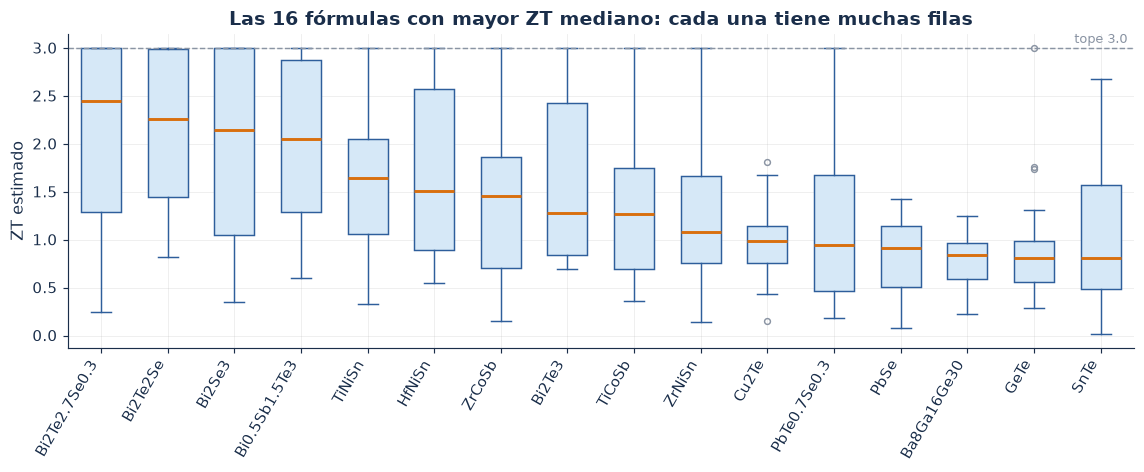

Filas con ZT exactamente 3.0: 36  (valores recortados: no son mediciones reales)


In [4]:
orden = df.groupby("formula")["ZT_estimated"].median().sort_values(ascending=False).index[:16]
fig, ax = plt.subplots(figsize=(11, 4.6))
datos_box = [df.loc[df.formula == f, "ZT_estimated"].values for f in orden]
ax.boxplot(datos_box, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor="#D6E8F7", edgecolor=AZUL), medianprops=dict(color=NARANJA, lw=2),
           whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL), flierprops=dict(markeredgecolor=GRIS, markersize=4))
ax.set_xticks(range(1, len(orden) + 1)); ax.set_xticklabels(orden, rotation=60, ha="right")
ax.axhline(3.0, color=GRIS, ls="--", lw=1); ax.text(16.4, 3.02, "tope 3.0", color=GRIS, ha="right", va="bottom", fontsize=9)
ax.set_ylabel("ZT estimado"); ax.set_title("Las 16 fórmulas con mayor ZT mediano: cada una tiene muchas filas")
plt.tight_layout(); plt.show()
print(f"Filas con ZT exactamente 3.0: {(df.ZT_estimated == 3.0).sum()}  (valores recortados: no son mediciones reales)")

Un mismo material puede aparecer con ZT de 0.3 y de 3.0. Usar el valor máximo (o una sola fila)
para elegir sería elegir el ruido. Usaremos la **mediana** y, como criterio prudente, el
**percentil 25** de cada fórmula: el valor que el material supera en 3 de cada 4 registros.

### Hallazgo 3: los descriptores Magpie vienen con ruido

In [5]:
var_magpie = df.groupby("formula")[MAGPIE].std().mean().round(2)
print("Desviación estándar promedio DENTRO de una misma fórmula (debería ser 0):")
print(var_magpie.to_string())
print(f"\nPeso atómico medio negativo (imposible): {(df.MagpieData_mean_AtomicWeight < 0).sum()} filas")
print(f"Electrones de valencia promedio negativos (imposible): {(df.MagpieData_mean_NValence < 0).sum()} filas")

Desviación estándar promedio DENTRO de una misma fórmula (debería ser 0):
MagpieData_mean_AtomicWeight          40.89
MagpieData_mean_MeltingT             345.88
MagpieData_mean_Electronegativity      0.21
MagpieData_mean_NValence               1.47
MagpieData_mean_CovalentRadius        29.73
MagpieData_mean_CohesiveEnergy         1.02

Peso atómico medio negativo (imposible): 2 filas
Electrones de valencia promedio negativos (imposible): 3 filas


Los descriptores Magpie dependen **solo de la composición**: para la misma fórmula deberían ser
idénticos. Aquí cambian de fila a fila y hay valores físicamente imposibles. Conviene
recalcularlos con matminer (Día 1) o no usarlos. Detectar esto es parte del 40 % de la rúbrica.

### Hallazgo 4: ZT_estimated es casi exactamente S²σT/κ

Correlación ZT_estimated vs S²σT/κ (T = 600 K): r = 0.881
Cociente ZT_estimated / (S²σT/κ): mediana 1.00, 50 % central entre 0.89 y 1.11


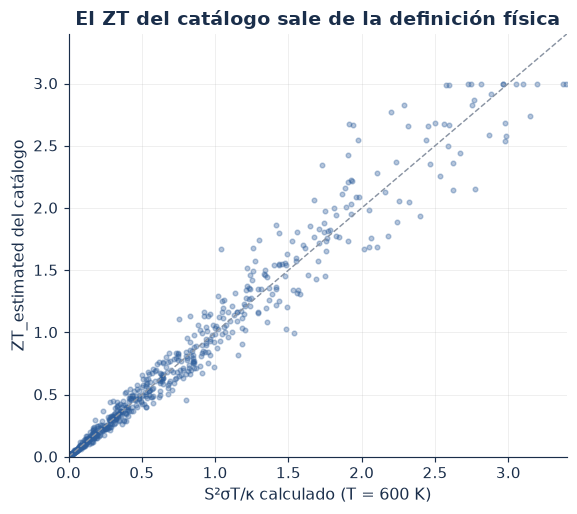

In [6]:
T = 600  # K, según el brief
df["ZT_fisica"] = (df.seebeck_uV_K * 1e-6) ** 2 * df.sigma_S_m * T / df.kappa_W_mK
r = np.corrcoef(df.ZT_fisica, df.ZT_estimated)[0, 1]
cociente = (df.ZT_estimated / df.ZT_fisica).replace([np.inf, -np.inf], np.nan)
print(f"Correlación ZT_estimated vs S²σT/κ (T = 600 K): r = {r:.3f}")
print(f"Cociente ZT_estimated / (S²σT/κ): mediana {cociente.median():.2f}, 50 % central entre {cociente.quantile(.25):.2f} y {cociente.quantile(.75):.2f}")

fig, ax = plt.subplots(figsize=(5.6, 5))
ax.scatter(df.ZT_fisica, df.ZT_estimated, s=10, alpha=0.35, color=AZUL)
lim = [0, 3.4]; ax.plot(lim, lim, "--", color=GRIS, lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="S²σT/κ calculado (T = 600 K)", ylabel="ZT_estimated del catálogo",
       title="El ZT del catálogo sale de la definición física")
plt.tight_layout(); plt.show()

Si ZT ya viene en la tabla y además se puede calcular con S, σ y κ, **no hace falta un modelo de
ML para ordenar este catálogo**. Un modelo solo aporta si queremos estimar ZT de materiales que
**no** están en la tabla, a partir de la composición. Eso es lo que prueba la Sección 2.

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 2. ¿Sirve un modelo? Validación honesta</b></div>

Comparamos cuatro formas de predecir ZT con **dos esquemas de validación** de 5 particiones:

- **KFold aleatorio:** el que se usa por defecto. Mezcla filas de una misma fórmula entre entrenamiento y prueba.
- **GroupKFold por fórmula:** las fórmulas de prueba nunca se vieron. Es la pregunta real: *¿qué pasa con un material nuevo?*

Modelos: (a) línea base, la mediana de su familia; (b) Random Forest con descriptores Magpie;
(c) Random Forest con propiedades de transporte (S, σ, κ, gap); (d) la fórmula física S²σT/κ, sin ajustar nada.

In [7]:
y = df.ZT_estimated.values
grupos = df.formula.values
TRANSPORTE = ["seebeck_uV_K", "sigma_S_m", "kappa_W_mK", "bandgap_eV"]

def evaluar(esquema, nombre_esquema):
    filas = []
    divisiones = list(esquema.split(df, y, grupos) if isinstance(esquema, GroupKFold) else esquema.split(df, y))
    for nombre in ["Línea base: mediana de la familia", "RF con Magpie", "RF con transporte", "Física S²σT/κ (sin ML)"]:
        maes, r2s = [], []
        for tr, te in divisiones:
            if nombre.startswith("Línea"):
                med = df.iloc[tr].groupby("grupo").ZT_estimated.median()
                pred = df.iloc[te].grupo.map(med).fillna(np.median(y[tr])).values
            elif nombre.startswith("Física"):
                pred = df.ZT_fisica.values[te]
            else:
                cols = MAGPIE if "Magpie" in nombre else TRANSPORTE
                rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=0)
                rf.fit(df.iloc[tr][cols], y[tr]); pred = rf.predict(df.iloc[te][cols])
            maes.append(mean_absolute_error(y[te], pred)); r2s.append(r2_score(y[te], pred))
        filas.append({"validación": nombre_esquema, "modelo": nombre,
                      "MAE": f"{np.mean(maes):.2f} ± {np.std(maes):.2f}", "R²": f"{np.mean(r2s):.2f} ± {np.std(r2s):.2f}"})
    return filas

res = pd.DataFrame(evaluar(KFold(5, shuffle=True, random_state=0), "KFold aleatorio")
                   + evaluar(GroupKFold(5), "GroupKFold por fórmula"))
res

,validación,modelo,MAE,R²
0,KFold aleatorio,Línea base: mediana de la familia,0.34 ± 0.02,0.55 ± 0.02
1,KFold aleatorio,RF con Magpie,0.60 ± 0.02,0.08 ± 0.04
2,KFold aleatorio,RF con transporte,0.13 ± 0.01,0.92 ± 0.01
3,KFold aleatorio,Física S²σT/κ (sin ML),0.15 ± 0.02,0.50 ± 0.34
4,GroupKFold por fórmula,Línea base: mediana de la familia,0.34 ± 0.07,0.54 ± 0.12
5,GroupKFold por fórmula,RF con Magpie,0.60 ± 0.03,0.05 ± 0.07
6,GroupKFold por fórmula,RF con transporte,0.14 ± 0.03,0.90 ± 0.02
7,GroupKFold por fórmula,Física S²σT/κ (sin ML),0.15 ± 0.04,0.46 ± 0.41


**Cómo leer la tabla** (media ± desviación entre las 5 particiones):

- **La línea base gana a Magpie.** Predecir "la mediana de su familia" da un MAE de 0.34. El
  Random Forest con descriptores Magpie da 0.60, peor que la línea base, con R² cercano a 0.
  Con descriptores que cambian de fila a fila (Hallazgo 3), el modelo no aprende nada útil de la composición.
- **KFold y GroupKFold dan casi lo mismo aquí.** Con estos datos no hay ni siquiera memorización
  que aprovechar. Aun así, GroupKFold es la pregunta correcta (*¿y con un material nuevo?*) y
  es la que hay que reportar.
- **El RF con transporte parece excelente (R² ≈ 0.9), pero es trampa conceptual:** S, σ y κ
  **son** el ZT. Si ya medimos S, σ y κ, calculamos ZT directamente y el modelo sobra.
- **La fórmula física sin ML** tiene MAE de 0.15 con un R² inestable: en los registros con κ
  muy bajo da valores por encima del tope de 3.0 que trae el catálogo.

**Decisión del pipeline:** para ordenar el catálogo no usamos ML. Usamos los datos agregados por
fórmula, con un criterio prudente frente a la dispersión, y reglas de dominio que el modelo no conoce.
Que un equipo llegue aquí y lo justifique vale más que un R² alto.

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 3. Resultado: la lista corta de 10 candidatos</b></div>

**Paso 1. Una fila por material.** Mediana y percentil 25 de ZT, número de registros, costo mediano.

**Paso 2. Reglas de dominio** (lo que un modelo no sabe):

- **Ventana de temperatura.** El escape trabaja a 400 a 700 °C. Los calcogenuros de bismuto
  (familia Bi₂Te₃) rinden cerca de ambiente y se degradan por encima de unos 250 °C. Su ZT alto
  en el catálogo no aplica a este cliente: se **excluyen** y se reportan aparte.
- **Regulación.** Pb, Tl y Cd son una bandera para el sector automotriz. No se excluyen, pero
  como máximo uno en la lista y marcado.
- **Diversificar.** Máximo 3 por familia, para que un problema de síntesis no tumbe toda la lista.

**Paso 3. Puntaje y sensibilidad.** Puntaje = w · ZT prudente normalizado − (1 − w) · costo
normalizado. En vez de elegir un w "mágico", lo variamos de 0.5 a 0.9 y también probamos con la
mediana en lugar del percentil 25. La **frecuencia** con que cada material entra al top 10 es
nuestra medida de confianza en la selección.

In [8]:
agg = (df.groupby(["formula", "grupo"])
       .agg(n=("ZT_estimated", "size"), ZT_med=("ZT_estimated", "median"),
            ZT_p25=("ZT_estimated", lambda s: s.quantile(0.25)), ZT_p75=("ZT_estimated", lambda s: s.quantile(0.75)),
            costo=("costo_relativo", "median"))
       .reset_index())

FUERA_DE_VENTANA = {"Bi-chalcogenide"}
def banderas(f):
    b = []
    if any(el in f for el in ["Pb", "Tl", "Cd"]): b.append("tóxico (Pb/Tl/Cd)")
    if "Te" in f: b.append("Te escaso")
    return ", ".join(b)
agg["banderas"] = agg.formula.map(banderas)
agg["ventana_400_700C"] = ~agg.grupo.isin(FUERA_DE_VENTANA)

def top10(tabla, w, col_zt):
    t = tabla[tabla.ventana_400_700C].copy()
    zt = (t[col_zt] - t[col_zt].min()) / (t[col_zt].max() - t[col_zt].min())
    co = (t.costo - t.costo.min()) / (t.costo.max() - t.costo.min())
    t["puntaje"] = w * zt - (1 - w) * co
    t = t.sort_values("puntaje", ascending=False)
    elegidos, por_familia, toxicos = [], {}, 0
    for _, r in t.iterrows():
        if por_familia.get(r.grupo, 0) >= 3: continue
        es_toxico = "tóxico" in r.banderas
        if es_toxico and toxicos >= 1: continue
        elegidos.append(r.formula); por_familia[r.grupo] = por_familia.get(r.grupo, 0) + 1; toxicos += es_toxico
        if len(elegidos) == 10: break
    return elegidos

escenarios = [(w, c) for w in np.linspace(0.5, 0.9, 9) for c in ["ZT_p25", "ZT_med"]]
conteo = pd.Series(0, index=agg.formula)
for w, c in escenarios:
    conteo[top10(agg, w, c)] += 1
agg["estabilidad_%"] = agg.formula.map(conteo / len(escenarios) * 100).round(0)

lista = top10(agg, 0.7, "ZT_p25")    # escenario central
corta = agg.set_index("formula").loc[lista].reset_index()
# prioridad: primero lo robusto (entra en todos los escenarios), después lo que depende del peso del costo
corta = corta.sort_values(["estabilidad_%", "ZT_p25"], ascending=False).reset_index(drop=True)
corta.insert(0, "prioridad", ["1 · validar ya"] * 3 + ["2 · segunda tanda"] * 4 + ["3 · respaldo"] * 3)
print(f"Escenarios probados: {len(escenarios)}  (w de 0.5 a 0.9, con ZT_p25 y con ZT_med)")
corta[["prioridad", "formula", "grupo", "ZT_med", "ZT_p25", "n", "costo", "estabilidad_%", "banderas"]].round(2)

Escenarios probados: 18  (w de 0.5 a 0.9, con ZT_p25 y con ZT_med)


,prioridad,formula,grupo,ZT_med,ZT_p25,n,costo,estabilidad_%,banderas
0,1 · validar ya,TiNiSn,Half-Heusler,1.65,1.06,18,1.23,100.0,
1,1 · validar ya,HfNiSn,Half-Heusler,1.51,0.89,18,1.18,100.0,
2,1 · validar ya,Cu2Te,Telluride-other,0.99,0.75,14,1.96,100.0,Te escaso
3,2 · segunda tanda,Ba8Ga16Ge30,Clathrate,0.84,0.58,14,2.09,100.0,
4,2 · segunda tanda,Sr8Ga16Ge30,Clathrate,0.77,0.54,20,2.04,100.0,
5,2 · segunda tanda,GeTe,Telluride-other,0.81,0.55,18,2.55,83.0,Te escaso
6,2 · segunda tanda,SnTe,Telluride-other,0.81,0.49,21,2.38,83.0,Te escaso
7,3 · respaldo,Ba8Al16Si30,Clathrate,0.49,0.37,15,1.84,72.0,
8,3 · respaldo,ZrNiSn,Half-Heusler,1.08,0.76,18,1.23,50.0,
9,3 · respaldo,PbS,Pb-chalcogenide,0.66,0.53,17,1.72,50.0,tóxico (Pb/Tl/Cd)


In [9]:
fuera = agg[~agg.ventana_400_700C].sort_values("ZT_med", ascending=False)
print("Excluidos por temperatura (buenos candidatos para OTRO cliente, cerca de ambiente):")
print(fuera[["formula", "ZT_med", "ZT_p25", "costo"]].round(2).to_string(index=False))

Excluidos por temperatura (buenos candidatos para OTRO cliente, cerca de ambiente):
      formula  ZT_med  ZT_p25  costo
Bi2Te2.7Se0.3    2.44    1.29   2.14
     Bi2Te2Se    2.26    1.45   2.54
       Bi2Se3    2.14    1.04   2.67
Bi0.5Sb1.5Te3    2.05    1.29   2.56
       Bi2Te3    1.28    0.84   2.77


**Cómo se defiende la lista:**

- Las prioridades se ordenan primero por estabilidad y después por ZT prudente.
- Los materiales con estabilidad cercana al 100 % entran al top 10 con cualquier peso razonable
  entre desempeño y costo. Son la parte sólida de la recomendación.
- Los de estabilidad baja dependen de cuánto pese el costo. Ahí la decisión es del cliente, no del modelo.
- La lista se basa en el **percentil 25**: es prudente a propósito, porque el cliente paga por
  cada síntesis fallida.

<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 4. Comunicación al cliente</b></div>

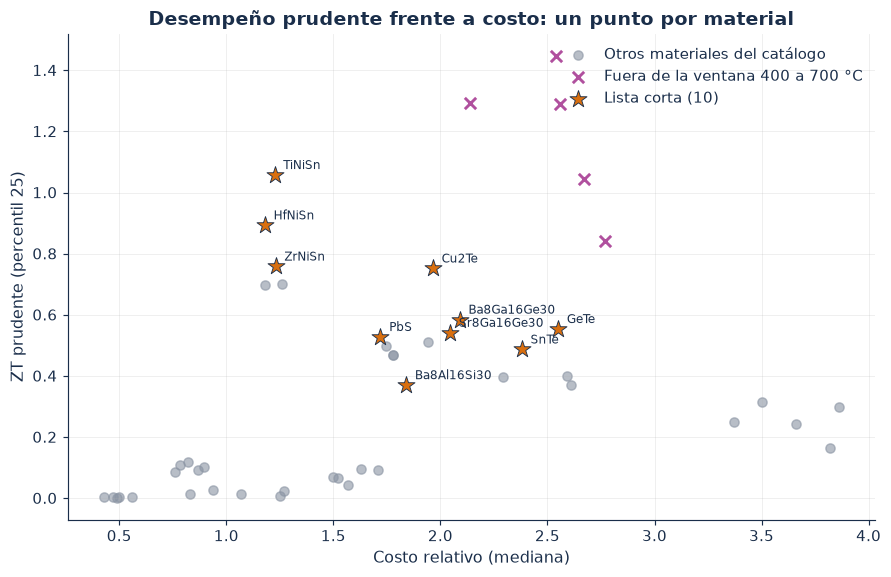

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 5.6))
resto = agg[agg.ventana_400_700C & ~agg.formula.isin(lista)]
ax.scatter(resto.costo, resto.ZT_p25, s=40, color=GRIS, alpha=0.6, label="Otros materiales del catálogo")
ax.scatter(fuera.costo, fuera.ZT_p25, s=60, marker="x", color=PURPURA, label="Fuera de la ventana 400 a 700 °C")
ax.scatter(corta.costo, corta.ZT_p25, s=150, marker="*", color=NARANJA, edgecolor=TINTA, lw=0.6, zorder=3, label="Lista corta (10)")
for _, r in corta.iterrows():
    ax.annotate(r.formula, (r.costo, r.ZT_p25), xytext=(6, 4), textcoords="offset points", fontsize=8.5, color=TINTA)
ax.set(xlabel="Costo relativo (mediana)", ylabel="ZT prudente (percentil 25)",
       title="Desempeño prudente frente a costo: un punto por material")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

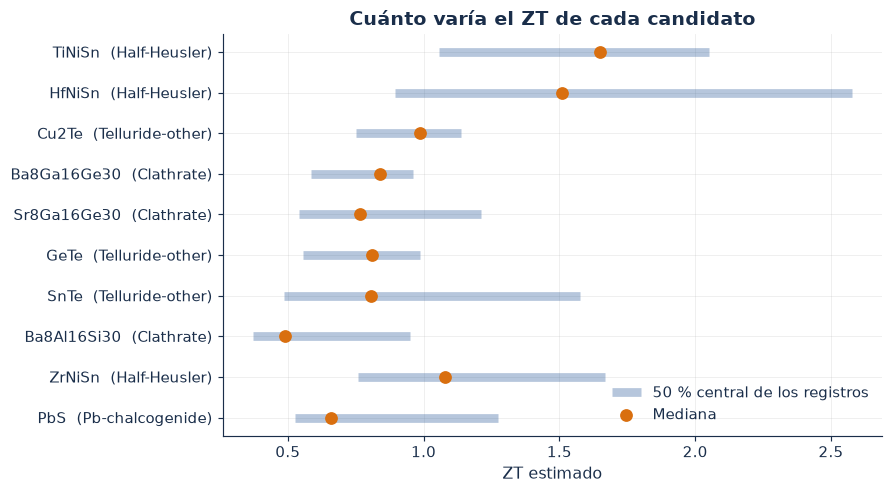

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
c = corta.iloc[::-1].reset_index(drop=True)
ax.hlines(range(len(c)), c.ZT_p25, c.ZT_p75, color=AZUL, lw=6, alpha=0.35, label="50 % central de los registros")
ax.scatter(c.ZT_med, range(len(c)), color=NARANJA, s=60, zorder=3, label="Mediana")
ax.set_yticks(range(len(c))); ax.set_yticklabels([f"{f}  ({g})" for f, g in zip(c.formula, c.grupo)])
ax.set_xlabel("ZT estimado"); ax.set_title("Cuánto varía el ZT de cada candidato")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [12]:
top3 = ", ".join(corta.formula[:3])
print(f"""PÁRRAFO PARA EL CLIENTE

Revisamos los 800 registros del catálogo, que corresponden a 49 materiales distintos.
Descartamos los que funcionan bien solo cerca de temperatura ambiente, porque su escape
trabaja entre 400 y 700 °C. De los restantes recomendamos 10, elegidos por un desempeño
prudente (el que el material alcanza en 3 de cada 4 registros) y por costo, sin repetir
más de tres de la misma familia química. Sugerimos sintetizar primero {top3}:
aparecen en la lista con cualquier balance razonable entre costo y desempeño.
Los valores de ZT son estimaciones; en el laboratorio suelen salir más bajos, así que
la lista sirve para decidir qué probar primero, no para prometer una eficiencia.""")

PÁRRAFO PARA EL CLIENTE

Revisamos los 800 registros del catálogo, que corresponden a 49 materiales distintos.
Descartamos los que funcionan bien solo cerca de temperatura ambiente, porque su escape
trabaja entre 400 y 700 °C. De los restantes recomendamos 10, elegidos por un desempeño
prudente (el que el material alcanza en 3 de cada 4 registros) y por costo, sin repetir
más de tres de la misma familia química. Sugerimos sintetizar primero TiNiSn, HfNiSn, Cu2Te:
aparecen en la lista con cualquier balance razonable entre costo y desempeño.
Los valores de ZT son estimaciones; en el laboratorio suelen salir más bajos, así que
la lista sirve para decidir qué probar primero, no para prometer una eficiencia.


<div style="background:#1A2E4A;color:white;padding:10px 18px;border-radius:8px;margin-top:14px;"><b>Sección 5. Limitaciones y próximos pasos</b></div>

- **ZT estimado no es ZT medido.** Los estimados de modelos o cálculos suelen ser optimistas
  (a menudo del orden de 2 veces). La lista ordena; los valores absolutos no son una promesa.
- **Una sola temperatura.** El catálogo da ZT a 600 K (unos 330 °C), por debajo de la ventana
  del cliente. Lo que importa es el ZT promedio entre 400 y 700 °C: hay que pedir datos en función de T.
- **Datos ruidosos.** Descriptores Magpie inconsistentes, valores imposibles y un tope artificial
  en ZT = 3. Antes de cualquier modelo: limpiar y recalcular descriptores con matminer.
- **El costo no es todo.** Faltan estabilidad térmica en ciclos, oxidación, compatibilidad con
  contactos y procesabilidad a escala. Las banderas de Pb y Te deben revisarse con el área regulatoria.
- **Revisar el costo del catálogo.** Por ejemplo, HfNiSn aparece con costo bajo, pero el hafnio
  es caro en el mercado. Un costo mal estimado cambia el orden de la lista.
- **Un modelo de composición no generaliza aquí** (Sección 2). Para explorar materiales fuera del
  catálogo haría falta un conjunto más grande y limpio, por ejemplo de Materials Project o de la literatura.
- **Próximo paso:** sintetizar los 3 de prioridad 1, medir ZT entre 400 y 700 °C y usar esos
  datos para recalibrar la lista (optimización bayesiana, Día 4).
- **Uso de asistentes de IA:** si se usaron para escribir código, declararlo y explicar qué se verificó a mano.